In [1]:
import pandas as pd
import numpy as np
import scanpy as sc

sc.settings.n_jobs = 30
sc.settings.verbosity = 0

import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

In [2]:
import ucell

In [3]:
isg_genes = ['MX1', 'MX2', 'OAS1', 'OAS2', 'OAS3', 'IFIT1', 'IFIT2', 'IFIT3']

In [4]:
all_inf_genes = ['MX1', 'MX2', 'OAS1', 'OAS2', 'OAS3', 'IFIT1', 'IFIT2', 'IFIT3',
                 'IFNA1', 'IFNB1', 'IRF7', 'IRF3', 'DDX58', 'IFIH1', 'TMEM173',
                 'SOCS1', 'SOCS3', 'USP18', 'PIAS1', 'TRIM21', 'TRIM26', 'TNFAIP3', 'NFKBIA', 'IRF2',
                 'DDX58', 'TRAF3', 'TBK1', 'NFKBIA', 'TNFAIP3', 'SOCS3', 'IRF7', 'STAT1', 'STAT2', 'IRF9', 'ISG15', 'IFI6']

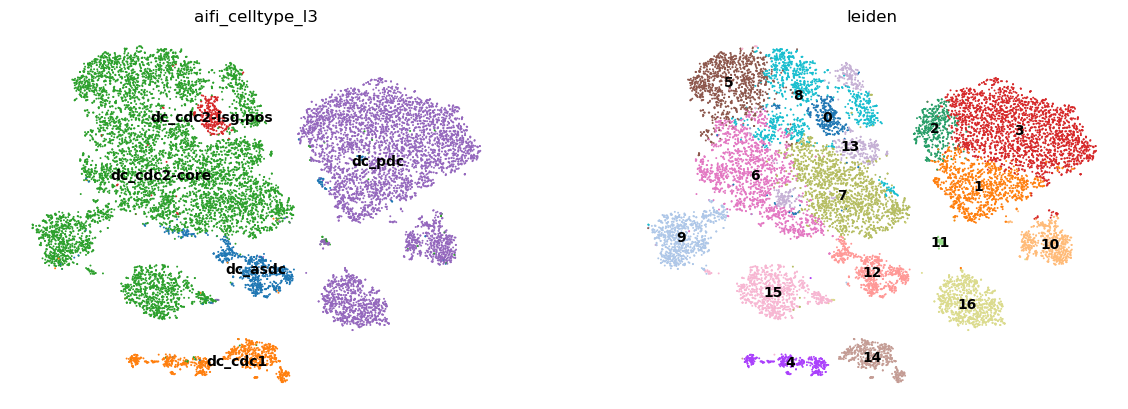

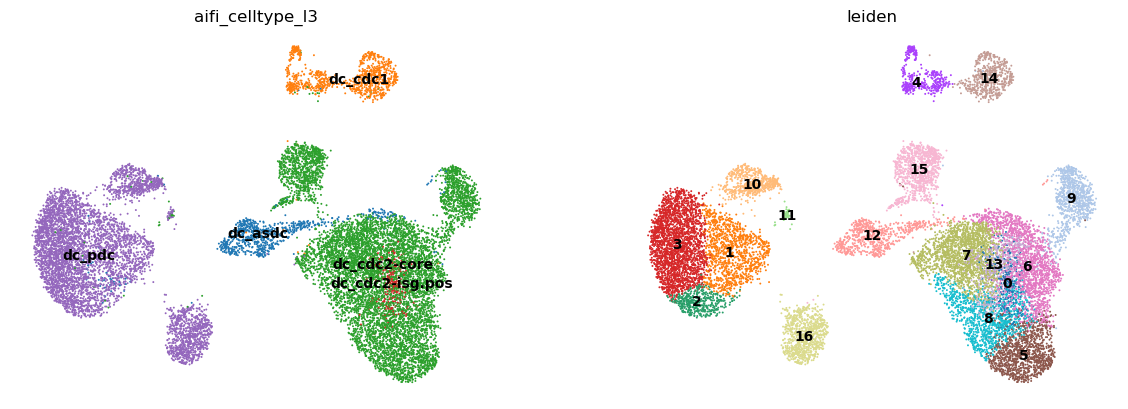

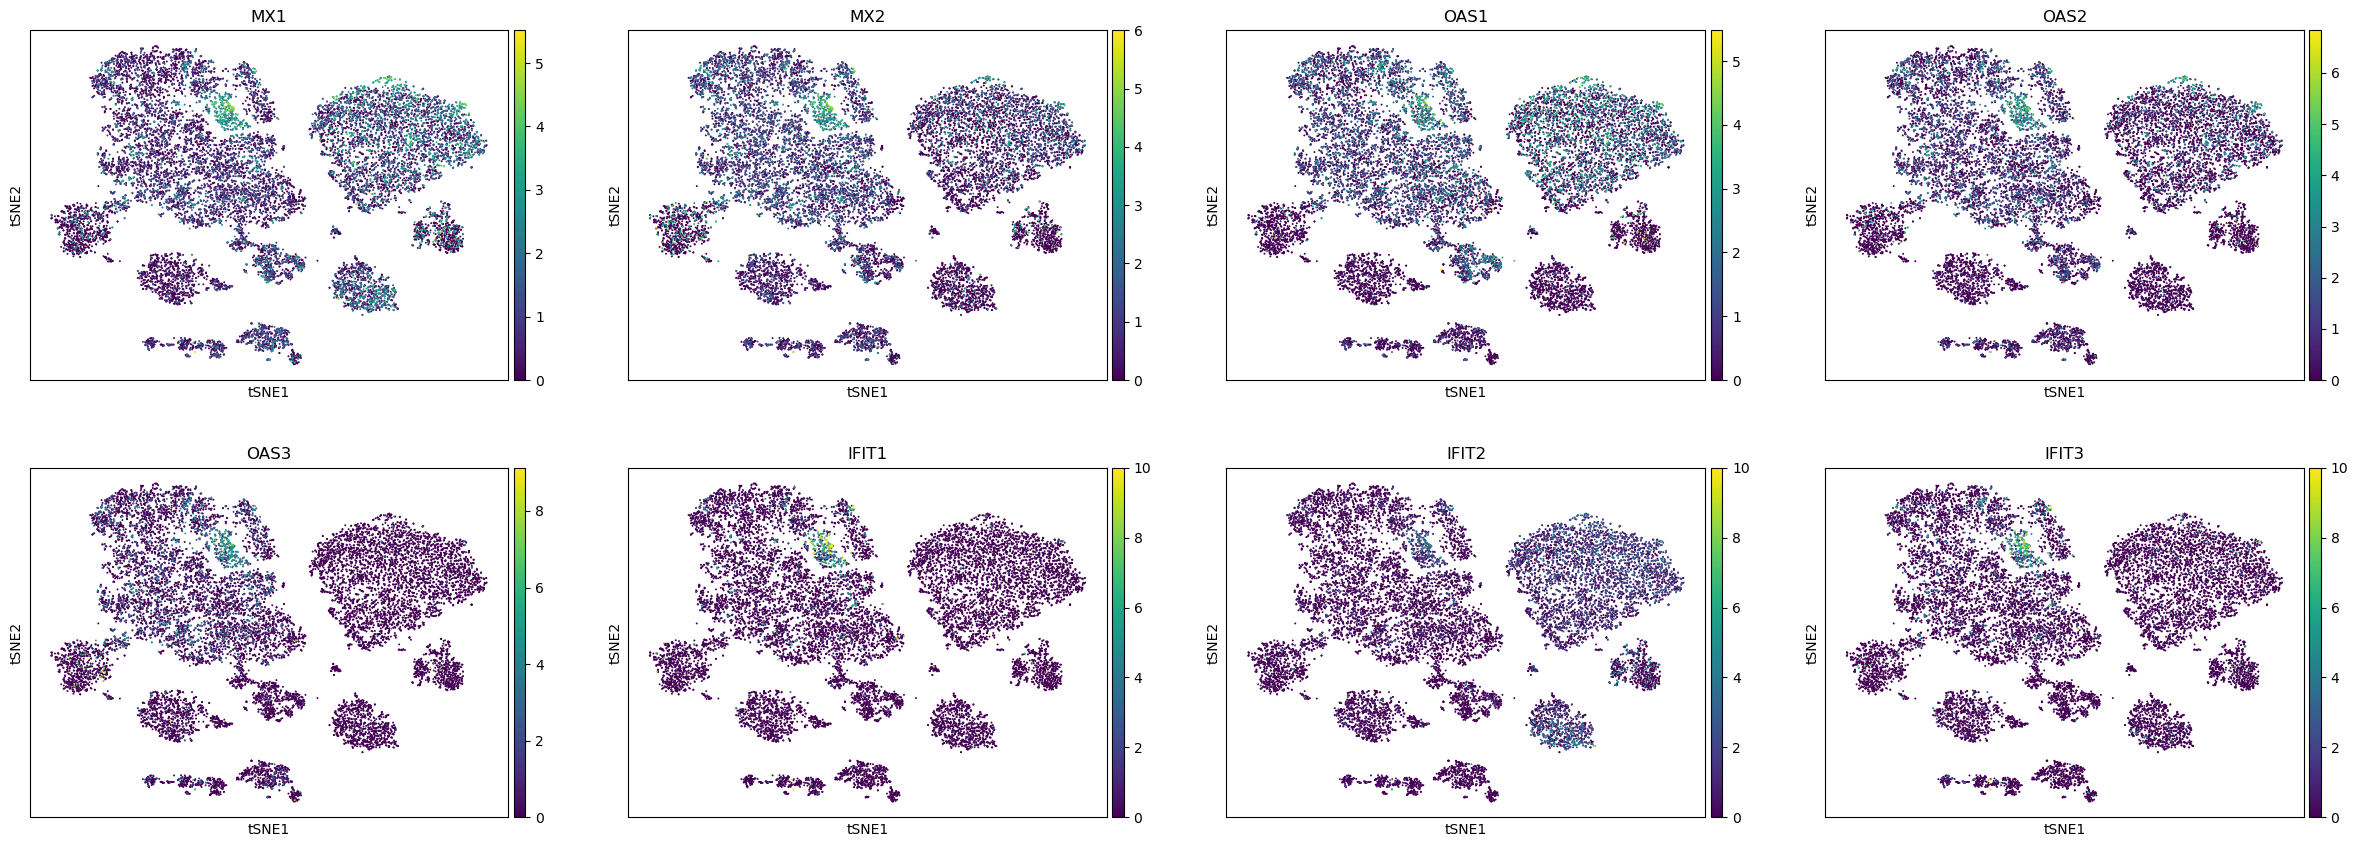

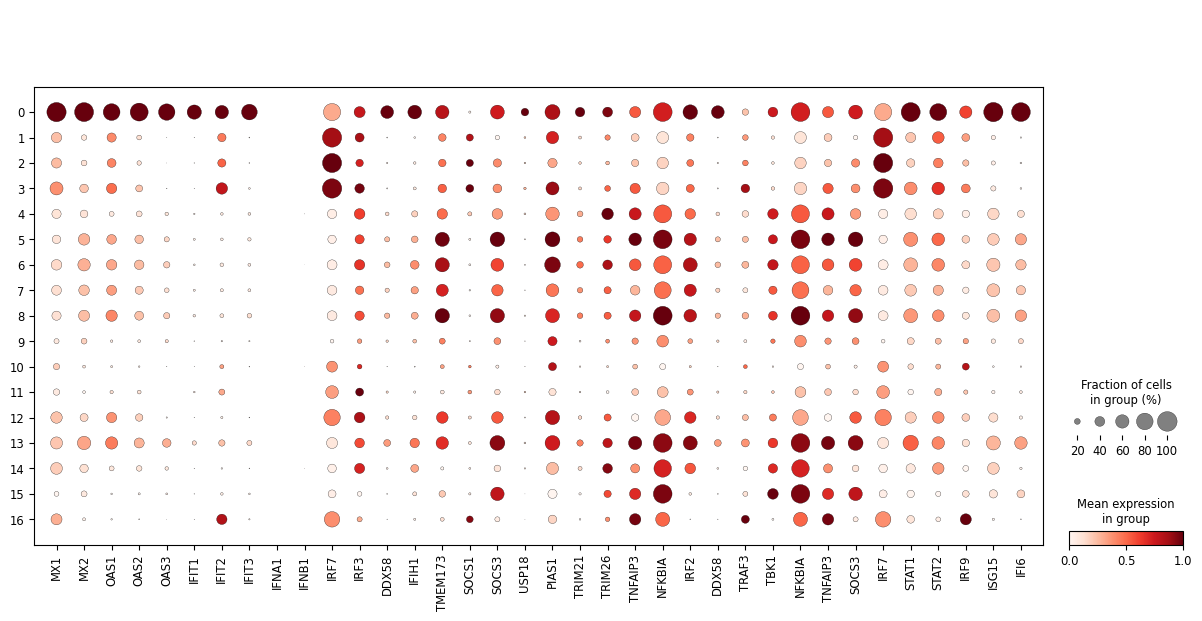

In [5]:
adata = sc.read_h5ad(
    '../../../data/rna/old-bmmc-celltypes/bmmc-dc-processed-harmony.h5ad')
sc.pl.tsne(adata, color=['aifi_celltype_l3', 'leiden'],
           legend_loc='on data', frameon=False)
sc.pl.umap(adata, color=['aifi_celltype_l3', 'leiden'],
           legend_loc='on data', frameon=False)
sc.pl.tsne(adata, color=isg_genes, use_raw=False)
sc.pl.dotplot(adata,
              var_names=all_inf_genes,
              groupby='leiden',
              use_raw=False,
              standard_scale='var')

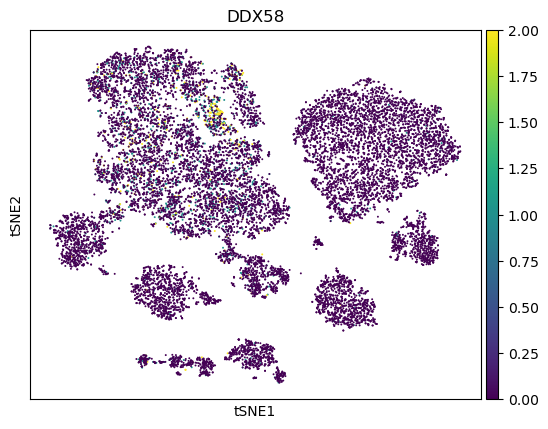

In [6]:
sc.pl.tsne(adata, color = 'DDX58', vmax='p99')

In [7]:
infg_genes = pd.read_csv('IFNa_IFNg_Scoring_ISGs_Mat.csv')

In [8]:
infg_genes['subset'].unique()

array(['Bcell', 'Monocyte', 'NK', 'Tcell', 'B_Memory', 'B_Naive',
       'CD4_Memory', 'CD4_Naive', 'CD8_Memory', 'CD8_Naive', 'MAIT',
       'NK.CD56dim', 'NK.CD56hi', 'Plasma', 'Treg', 'gdT', 'PBMC'],
      dtype=object)

In [ ]:
signatures = {
    # Type I IFN signature - genes common across DC subtypes
    "DC_Type_I_IFN": [
        'BST2', 'EIF2AK2', 'IFI6', 'IFITM2', 'IFITM3', 'IRF7', 'ISG15', 
        'ISG20', 'MX1', 'MX2', 'OAS1', 'OAS2', 'OAS3', 'OASL', 'PLSCR1', 
        'STAT1', 'STAT2', 'IFI44', 'IFI44L', 'IFIT2', 'IFIT3', 'IRF9', 'CMPK2'
    ],
    
    # Type II IFN signature - genes common across DC subtypes  
    "DC_Type_II_IFN": [
        'CIITA', 'GBP1', 'GBP2', 'HLA-DRA', 'HLA-DRB1', 'ICAM1', 'IDO1', 
        'IRF1', 'PSMB8', 'PSMB9', 'STAT1', 'TAP1', 'TAP2'
    ],
    
    # IFNb-skewed signature (from your data)
    "DC_IFNb_skewed": [
        'DDX60L', 'IFIH1', 'TLR3', 'TRIM14', 'DHX58', 'DDX60'
    ],
    
    # DC-specific markers for context
    "DC_markers": [
        'ITGAX', 'CD1C', 'CLEC9A', 'IRF8', 'BATF3', 'CLEC4C'
    ]
}

# Calculate UCell scores
ucell.add_scores(adata, signatures=signatures, maxRank=1000)

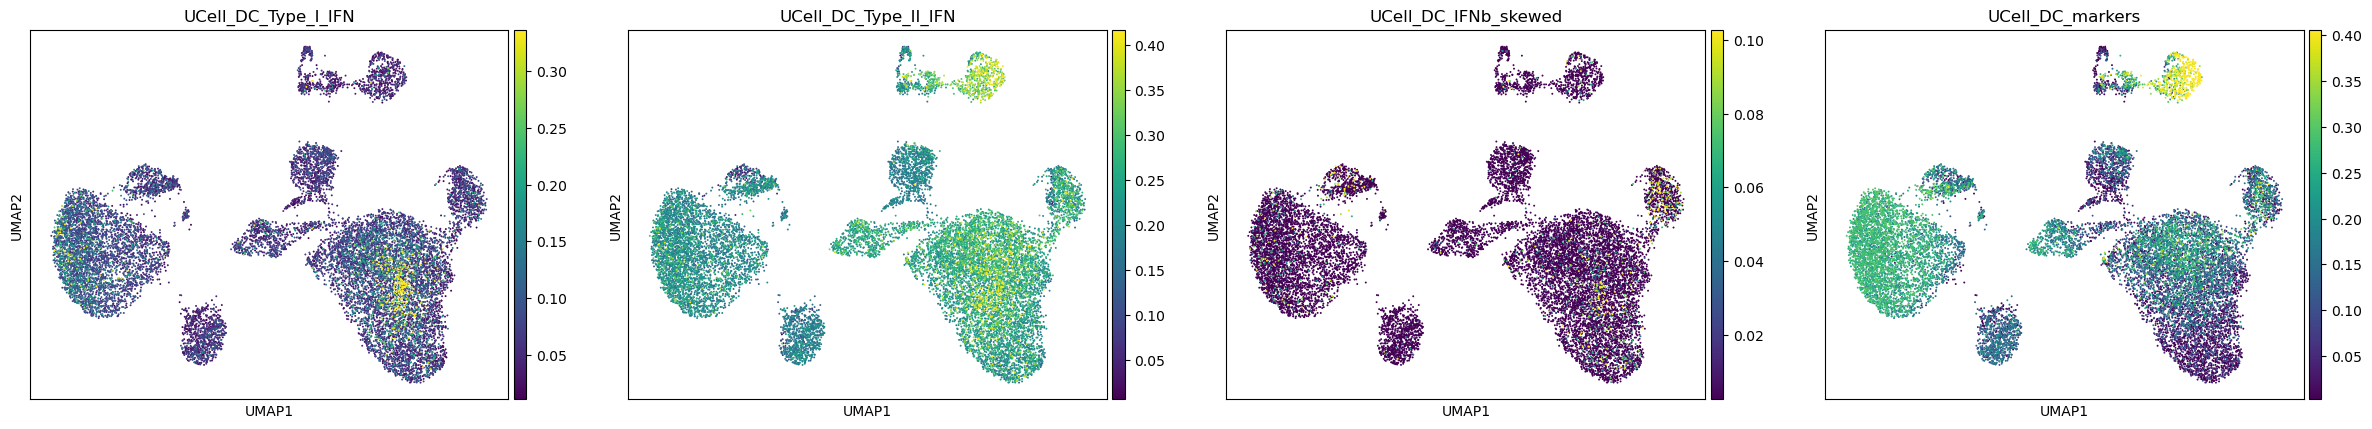

In [11]:
# Plot results
sc.pl.umap(
    adata,
    color=["UCell_" + k for k in signatures.keys()],
    ncols=4, vmax='p99'
)


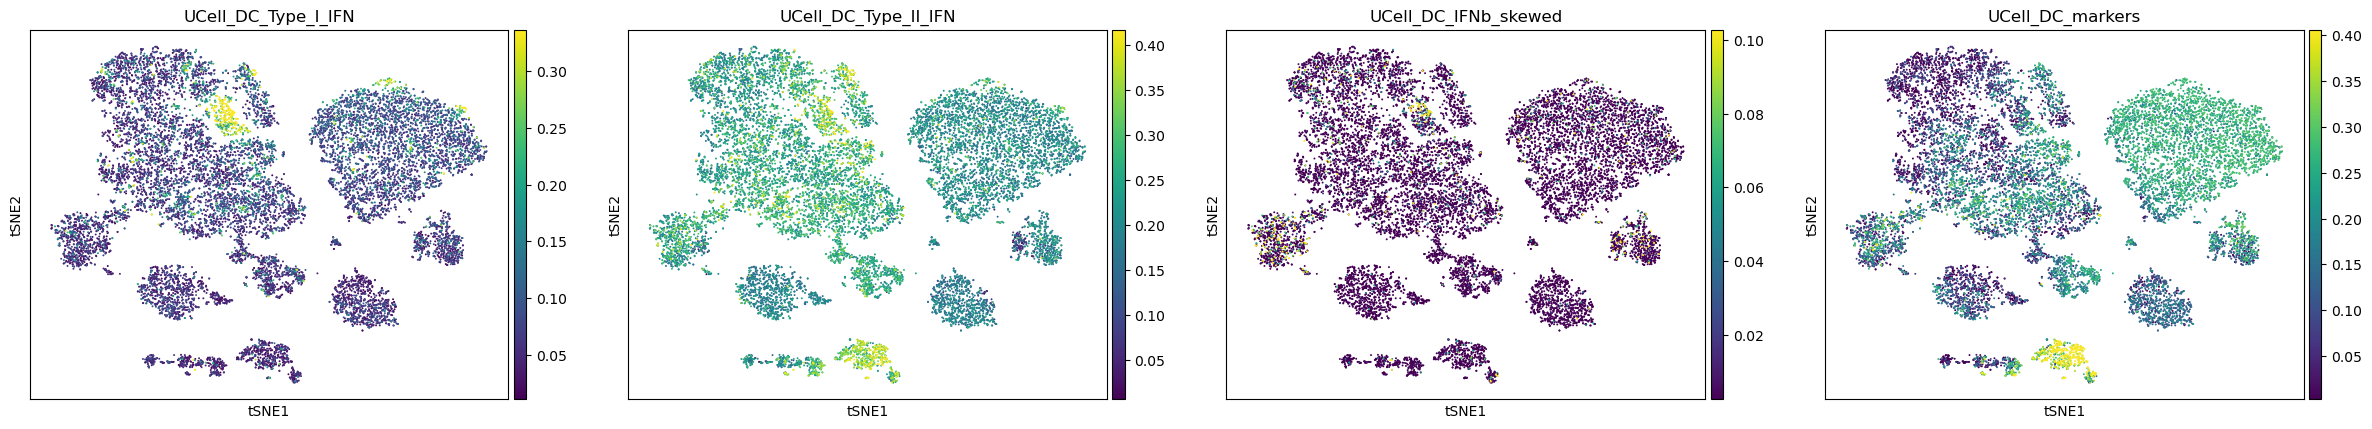

In [12]:
# Plot results
sc.pl.tsne(
    adata,
    color=["UCell_" + k for k in signatures.keys()],
    ncols=4, vmax='p99'
)


In [13]:
type1_scores = adata.obs['UCell_DC_Type_I_IFN'].values
type2_scores = adata.obs['UCell_DC_Type_II_IFN'].values

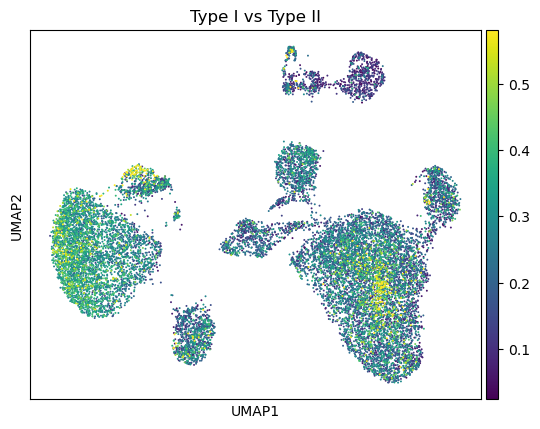

In [16]:
adata.obs['IFN_Type_Ratio'] = type1_scores / (type1_scores + type2_scores)
sc.pl.umap(adata, color='IFN_Type_Ratio', title='Type I vs Type II', vmax='p99')

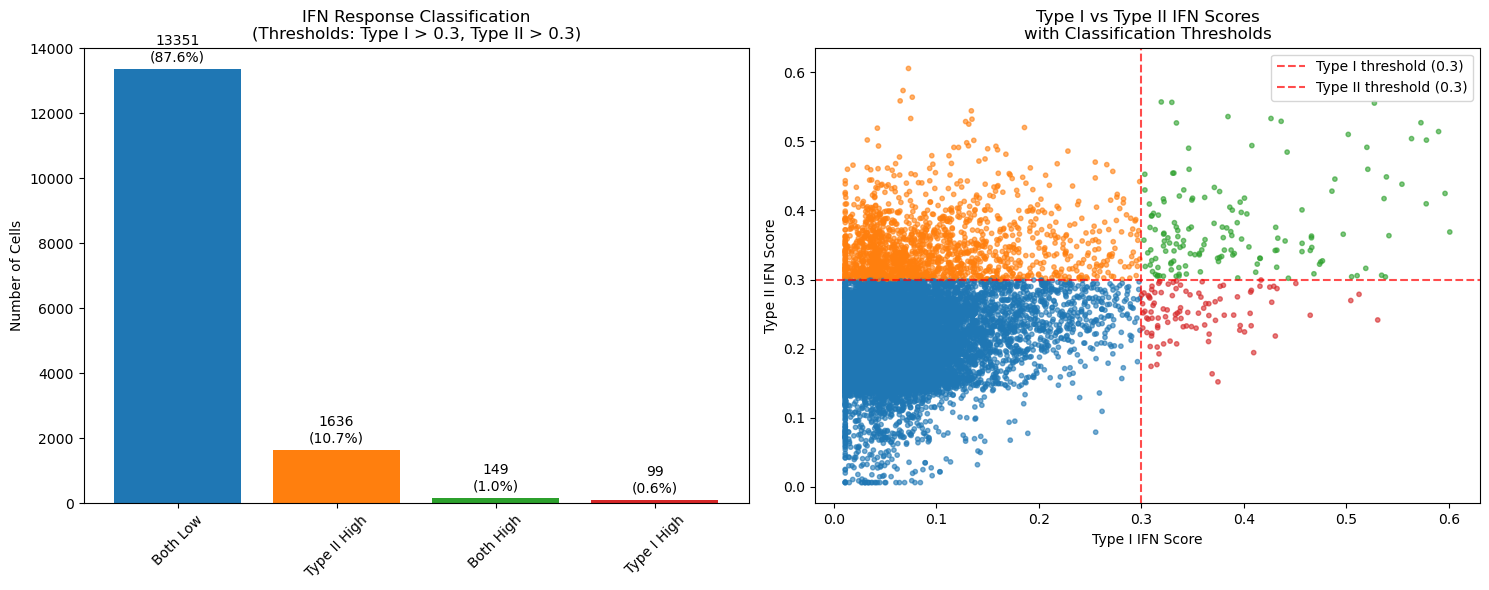


IFN Classification Summary:
Both Low       :  13351 cells ( 87.6%)
Type II High   :   1636 cells ( 10.7%)
Both High      :    149 cells (  1.0%)
Type I High    :     99 cells (  0.6%)

Threshold Analysis:
Type I IFN score range: 0.011 - 0.601
Type II IFN score range: 0.006 - 0.606
Suggested thresholds (75th percentile):
  Type I: 0.090
  Type II: 0.257


In [17]:
import matplotlib.pyplot as plt

# Define thresholds (you can adjust these based on your data distribution)
type1_threshold = 0.3  # Adjust based on your UCell score distribution
type2_threshold = 0.3  # Adjust based on your UCell score distribution

# Create categorical classifications
def classify_ifn_response(row):
    type1_high = row['UCell_DC_Type_I_IFN'] > type1_threshold
    type2_high = row['UCell_DC_Type_II_IFN'] > type2_threshold
    
    if type1_high and type2_high:
        return 'Both High'
    elif type1_high and not type2_high:
        return 'Type I High'
    elif not type1_high and type2_high:
        return 'Type II High'
    else:
        return 'Both Low'

# Apply classification
adata.obs['IFN_Classification'] = adata.obs.apply(classify_ifn_response, axis=1)

# Create bar plot
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Overall distribution
classification_counts = adata.obs['IFN_Classification'].value_counts()
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red
bars1 = axes[0].bar(classification_counts.index, classification_counts.values, color=colors)
axes[0].set_title(f'IFN Response Classification\n(Thresholds: Type I > {type1_threshold}, Type II > {type2_threshold})')
axes[0].set_ylabel('Number of Cells')
axes[0].tick_params(axis='x', rotation=45)

# Add percentage labels on bars
total_cells = len(adata)
for bar, count in zip(bars1, classification_counts.values):
    height = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., height + total_cells*0.01,
                f'{count}\n({count/total_cells*100:.1f}%)', 
                ha='center', va='bottom')

# Plot 2: By cell type (if available)
if 'cell_type' in adata.obs.columns:
    # Create crosstab
    crosstab = pd.crosstab(adata.obs['cell_type'], adata.obs['IFN_Classification'], normalize='index')
    
    # Plot stacked bar chart
    crosstab.plot(kind='bar', stacked=True, ax=axes[1], color=colors)
    axes[1].set_title('IFN Response by Cell Type\n(Proportions)')
    axes[1].set_ylabel('Proportion of Cells')
    axes[1].set_xlabel('Cell Type')
    axes[1].legend(title='IFN Classification', bbox_to_anchor=(1.05, 1), loc='upper left')
    axes[1].tick_params(axis='x', rotation=45)
else:
    # Alternative plot: Scatter plot with thresholds
    scatter = axes[1].scatter(adata.obs['UCell_DC_Type_I_IFN'], 
                            adata.obs['UCell_DC_Type_II_IFN'],
                            c=[colors[list(classification_counts.index).index(x)] for x in adata.obs['IFN_Classification']],
                            alpha=0.6, s=10)
    
    # Add threshold lines
    axes[1].axvline(x=type1_threshold, color='red', linestyle='--', alpha=0.7, label=f'Type I threshold ({type1_threshold})')
    axes[1].axhline(y=type2_threshold, color='red', linestyle='--', alpha=0.7, label=f'Type II threshold ({type2_threshold})')
    
    axes[1].set_xlabel('Type I IFN Score')
    axes[1].set_ylabel('Type II IFN Score')
    axes[1].set_title('Type I vs Type II IFN Scores\nwith Classification Thresholds')
    axes[1].legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nIFN Classification Summary:")
print("=" * 40)
for category in classification_counts.index:
    count = classification_counts[category]
    percentage = count / total_cells * 100
    print(f"{category:15s}: {count:6d} cells ({percentage:5.1f}%)")

# Optional: Show threshold sensitivity
print(f"\nThreshold Analysis:")
print(f"Type I IFN score range: {adata.obs['UCell_DC_Type_I_IFN'].min():.3f} - {adata.obs['UCell_DC_Type_I_IFN'].max():.3f}")
print(f"Type II IFN score range: {adata.obs['UCell_DC_Type_II_IFN'].min():.3f} - {adata.obs['UCell_DC_Type_II_IFN'].max():.3f}")
print(f"Suggested thresholds (75th percentile):")
print(f"  Type I: {adata.obs['UCell_DC_Type_I_IFN'].quantile(0.75):.3f}")
print(f"  Type II: {adata.obs['UCell_DC_Type_II_IFN'].quantile(0.75):.3f}")